In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm
import scipy
from scipy.linalg import sqrtm
import scipy.linalg as la
import time
from tqdm.notebook import tqdm 


In [2]:
def gr_zinengr(E, H, T, T_dx, Nd):
    I_nd = np.eye(Nd, dtype=complex)
    
    Tmat = np.block([
        [np.linalg.inv(T) @ (E - H), -np.linalg.inv(T) @ T.conj().T],
        [I_nd, np.zeros((Nd, Nd), dtype=complex)]
    ])

    eigvals, eigvecs = np.linalg.eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    S1 = eigvecs[:Nd, :Nd] 
    S2 = eigvecs[Nd:, :Nd]  

    g = np.linalg.inv(E - H - T @ S1 @ np.linalg.inv(S2))
    
    # 计算自能 Sigma
    Sigma = T_dx.conj().T @ g @ T_dx
    Gamma = 1j * (Sigma - Sigma.conj().T)
    return Sigma, Gamma

def Green_device_1(Nd, N, E, H, V, Sigma_r, Sigma_l):
    ALR = E - H
    
    # Gnn (从右向左递归)
    Gnn = np.zeros((N, Nd, Nd), dtype=complex)
    Gnn[N-1] = np.linalg.inv(ALR - Sigma_r)  # N-1 对应最右侧格点
    for n in range(N-2, 0, -1):              
        Gnn[n] = np.linalg.inv(ALR - V @ Gnn[n+1] @ V.conj().T)
    Gnn[0] = np.linalg.inv(ALR - V @ Gnn[1] @ V.conj().T - Sigma_l)
    
    # G1n 
    G1n = Gnn[0].copy()
    for n in range(1, N):
        G1n = G1n @ V @ Gnn[n]
        
    # Gnn2 (从左向右递归)
    Gnn2 = np.zeros((N, Nd, Nd), dtype=complex)
    Gnn2[0] = np.linalg.inv(ALR - Sigma_l)
    for n in range(1, N-1):
        Gnn2[n] = np.linalg.inv(ALR - V.conj().T @ Gnn2[n-1] @ V)
    Gnn2[N-1] = np.linalg.inv(ALR - V.conj().T @ Gnn2[N-2] @ V - Sigma_r)
    
    # Gn1
    Gn1 = Gnn2[N-1].copy()
    for n in range(N-2, -1, -1):
        Gn1 = Gn1 @ V.conj().T @ Gnn2[n]

    #Gnn2[N-1] (右下角)，Gnn[0] (左上角)，G1n (右上角)，Gn1 (左下角)

    return Gnn, G1n, Gnn2, Gn1

In [6]:

# ==========================================
# 2. 构造测试数据 (随机生成复数矩阵，测试纯数学等价性)
# ==========================================
Nd = 4
N = 6  # 假设器件有 6 层 (为了全空间矩阵能瞬间求逆，不用 3000 多)

np.random.seed(42)  # 固定随机种子以便复现
# 生成厄米矩阵作为中心区 Onsite 哈密顿量
H_q = np.random.rand(Nd, Nd) + 1j * np.random.rand(Nd, Nd)
H_q = H_q + H_q.conj().T 

# 生成任意跃迁矩阵和自能
T_12 = np.random.rand(Nd, Nd) + 1j * np.random.rand(Nd, Nd)
Sigma_l = np.random.rand(Nd, Nd) + 1j * np.random.rand(Nd, Nd)
Sigma_r = np.random.rand(Nd, Nd) + 1j * np.random.rand(Nd, Nd)

# 能量矩阵加上一点微小的虚部保证可逆
E_mat = (0.5 + 1j * 1e-6) * np.eye(Nd, dtype=complex)


# ==========================================
# 3. 分别调用两种方法
# ==========================================
# 方法 A：你写的大矩阵直接求逆法
G_DD_r = Gr_DD(Nd, N, E_mat, H_q, T_12, Sigma_r, Sigma_l)

# 方法 B：老师的递归法
Gnn, G1n, Gnn2, Gn1 = Green_device_1(Nd, N, E_mat, H_q, T_12, Sigma_r, Sigma_l)


# ==========================================
# 4. 提取四个角落进行验证对比
# ==========================================
# (1) 左上角: Gnn[0]
G_DD_TopLeft = G_DD_r[0:Nd, 0:Nd]
err_TopLeft = np.max(np.abs(Gnn[0] - G_DD_TopLeft))

# (2) 右下角: Gnn2[N-1]
G_DD_BottomRight = G_DD_r[(N-1)*Nd : N*Nd, (N-1)*Nd : N*Nd]
err_BottomRight = np.max(np.abs(Gnn2[N-1] - G_DD_BottomRight))

# (3) 右上角: G1n
G_DD_TopRight = G_DD_r[0:Nd, (N-1)*Nd : N*Nd]
err_TopRight = np.max(np.abs(G1n - G_DD_TopRight))

# (4) 左下角: Gn1
G_DD_BottomLeft = G_DD_r[(N-1)*Nd : N*Nd, 0:Nd]
err_BottomLeft = np.max(np.abs(Gn1 - G_DD_BottomLeft))

print("================= 验证结果 =================")
print(f"[左上角] Gnn[0]   与 G_DD_r 切片的最大误差: {err_TopLeft:.5e}")
print(f"[右下角] Gnn2[N-1] 与 G_DD_r 切片的最大误差: {err_BottomRight:.5e}")
print(f"[右上角] G1n      与 G_DD_r 切片的最大误差: {err_TopRight:.5e}")
print(f"[左下角] Gn1      与 G_DD_r 切片的最大误差: {err_BottomLeft:.5e}")
print("============================================")

NameError: name 'Gr_DD' is not defined

In [4]:
#参数1
dela = 0.25 * 1e-3
chaodaojiao = 0
m=2.5*10**(-3)
a=6.49 * 0.1
t =38 * dela
af =200 * 1e-4
mu = 4 * dela

#两边
hx=0    #0.5
hz=8 * dela #0.95
#(my = 0.954776)
Ul = -0.1 * t
saimanjiao = np.pi*0

#中间
mx=1.5 *np.sqrt(mu**2 + dela**2) #0.5
mz=0  #0.95
zhongjian_saimanjiao=np.pi*0.5

T_Tc=1e-3
Delta = dela#* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=int(np.floor(2 * 10**3 * 1 / a))
Nd=4
KBT=2 * dela * T_Tc / 3.5


#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao):
    if weizhi==1:
        Delta_X=np.zeros((2,2))
        HX_block=(Ul-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==2:
        Delta_X=Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= np.zeros((2,2))
        HX_block=(Ul-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(hx,hz,saimanjiao,1,chaodaojiao)
H_L_right_to_left_hop=H_hop(0)

#中间矩阵信息
H_center_to_L=H_hop(0)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao)
H_center_right_to_left_hop=H_hop(af)

H_R_to_center=H_hop(0)

#右边矩阵信息
H_R_onsite=H_onsite(hx,hz,saimanjiao,3,chaodaojiao)
H_R_right_to_left_hop=H_hop(0)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop #2到1

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center


Calculating Energy Points:   0%|          | 0/101 [00:00<?, ?it/s]

Elapsed time: 6.42 seconds


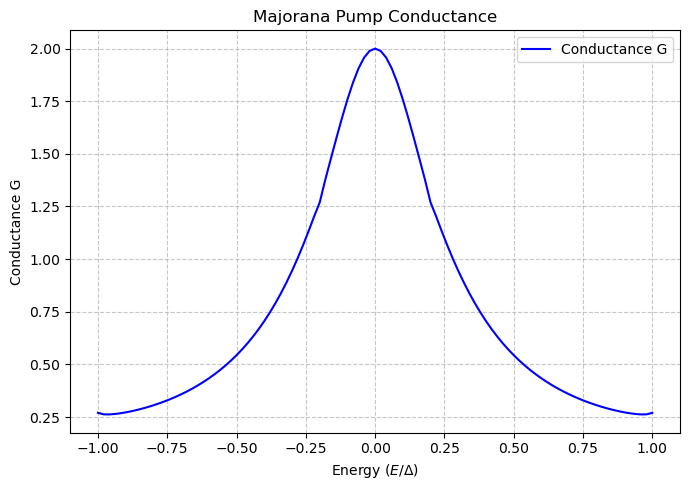

In [5]:
# 计时开始
start_time = time.time()
#N= 2 #
N=int(np.floor(2 * 10**3 * 1 / a))
Mdata = 101
Energy = np.linspace(-1, 1, Mdata)
G = np.zeros(Mdata, dtype=float)

# tqdm 将在 Jupyter 中显示进度条
for n in tqdm(range(Mdata), desc="Calculating Energy Points"):
    ep = Energy[n] * dela
    E_mat = (ep + 1j *1e-8) * np.eye(4, dtype=complex)

    # 计算电极格林函数
    Sigma_r, Gamma_r = gr_zinengr(E_mat, H_r,T_r, T_RD, Nd)
    Sigma_l, Gamma_l = gr_zinengr(E_mat, H_l,T_l, T_LD, Nd)
    #Sigma_r, Gamma_r = Green_lead_1(Nd, E_mat, H_r, T_r, T_RD)
    #Sigma_l, Gamma_l = Green_lead_1(Nd, E_mat, H_l, T_l, T_LD)

    # 提取电子与空穴块
    Gamma_ee_l = Gamma_l[0:2, 0:2]
    Gamma_ee_r = Gamma_r[0:2, 0:2]
    Gamma_hh_l = Gamma_l[2:4, 2:4]
    Gamma_hh_r = Gamma_r[2:4, 2:4]
    

    Gnn, G1n, Gnn2, Gn1 = Green_device_1(Nd, N, E_mat, H_q, T_12, Sigma_r, Sigma_l)
    
    # 提取末端格林函数 (索引改为 N-1)
    GNN = Gnn2[N-1]

    GLR_ee = G1n[0:2, 0:2]
    GLR_eh = G1n[0:2, 2:4]
    GRR_eh = GNN[0:2, 2:4]
    
    # 计算各个过程的透射率
    Tee = np.real(np.trace(Gamma_ee_l @ GLR_ee @ Gamma_ee_r @ GLR_ee.conj().T))
    T_CAR = np.real(np.trace(Gamma_ee_l @ GLR_eh @ Gamma_hh_r @ GLR_eh.conj().T))
    T_LAR = np.real(np.trace(Gamma_ee_r @ GRR_eh @ Gamma_hh_r @ GRR_eh.conj().T))
    
    # 最终电导计算
    G[n] = (Tee + T_CAR + 2 * T_LAR) 

# 输出耗时
print(f"Elapsed time: {time.time() - start_time:.2f} seconds")



plt.figure(figsize=(7, 5))
plt.plot(Energy, G, 'b-', linewidth=1.5, label='Conductance G')
plt.xlabel(r'Energy ($E/\Delta$)')
plt.ylabel('Conductance G')
plt.title('Majorana Pump Conductance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Calculating Energy Points:   0%|          | 0/101 [00:00<?, ?it/s]

Elapsed time: 6.21 seconds


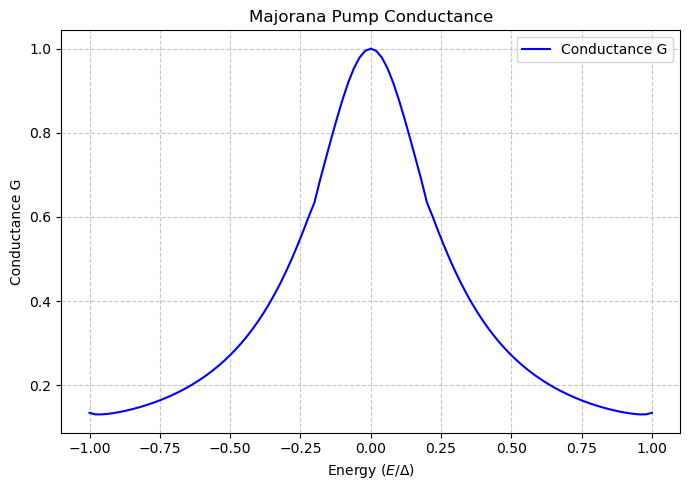

In [7]:
def Green_lead_1(Nd, E, H, V, V_cm):
    """计算电极的自能 Sigma 和展宽 Gamma"""
    T = np.zeros((2*Nd, 2*Nd), dtype=complex)
    
    # MATLAB: T(1:Nd,1:Nd)=V\(E-H); T(1:Nd,Nd+1:2*Nd)=-V\V';
    # 使用 np.linalg.solve 替代 MATLAB 的左除 \
    T[0:Nd, 0:Nd] = np.linalg.solve(V, E - H)
    T[0:Nd, Nd:2*Nd] = -np.linalg.solve(V, V.conj().T)
    T[Nd:2*Nd, 0:Nd] = np.eye(Nd)
    
    eigenvalues, eigenvectors = np.linalg.eig(T)
    
    # 按特征值绝对值排序
    order = np.argsort(np.abs(eigenvalues))
    
    S1 = eigenvectors[0:Nd, order[0:Nd]]
    S2 = eigenvectors[Nd:2*Nd, order[0:Nd]]
    
    # 表面格林函数
    g11 = np.linalg.inv((E - H) - V @ S1 @ np.linalg.inv(S2))
    Sigma = V_cm @ g11 @ V_cm.conj().T
    Gamma = 1j * (Sigma - Sigma.conj().T)
    
    return Sigma, Gamma

# 计时开始
start_time = time.time()

# --- 参数设置 (Parameter Setting) ---
NA = 2
# ================= 关键修改 =================
Nd = 4  # 原来的 N 改为了 Nd (格点内部自由度维度)
# ==========================================
delta = 0.25 * 1e-3
a = 6.49 * 0.1
scale = 1
t = 38 * delta
UR = 200 * 1e-4 / a
UR_L = 0
VL = -0.1 * t
mu = 4 * delta
hc = np.sqrt(mu**2 + delta**2)
h = 1.5 * hc
omega = 2 * np.pi
T_period = 2 * np.pi / omega
tt = 0
hl = 8 * delta

# ================= 关键修改 =================
N = int(np.floor(2 * 10**3 * scale / a))  # 原来的 M 改为了 N (器件层数)
# ==========================================

psi = np.pi/2
ee = 0
M_l = 20
aL = 1
ac = 1
tL = t * aL
alpha_L = 2 * UR_L

sigma_x = np.array([[0, 1], [1, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

eta = 1e-8
Mdata = 101
Energy = np.linspace(-1, 1, Mdata)
G = np.zeros(Mdata, dtype=float)

# --- 构造独立于能量 E 的哈密顿量分块矩阵 ---
hh0 = np.zeros((4, 4), dtype=complex)
hh0[0,0] = -mu + 2*t; hh0[1,1] = -mu + 2*t
hh0[2,2] =  mu - 2*t; hh0[3,3] =  mu - 2*t

hhl = np.zeros((4, 4), dtype=complex)
hhl[0,0] = -mu + 2*tL + VL; hhl[1,1] = -mu + 2*tL + VL
hhl[2,2] =  mu - 2*tL - VL; hhl[3,3] =  mu - 2*tL - VL

hhd = np.zeros((4, 4), dtype=complex)
hhd[0,3] = delta; hhd[3,0] = delta
hhd[1,2] = -delta; hhd[2,1] = -delta

vvt = np.zeros((4, 4), dtype=complex)
vvt[0,0] = -t; vvt[1,1] = -t
vvt[2,2] =  t; vvt[3,3] =  t

vvs = np.zeros((4, 4), dtype=complex)
vvs[0,0] = -1j*UR; vvs[1,1] = 1j*UR
vvs[2,2] = -1j*UR; vvs[3,3] = 1j*UR

vvs_L = np.zeros((4, 4), dtype=complex)
vvs_L[0,0] = -1j*UR_L; vvs_L[1,1] = 1j*UR_L
vvs_L[2,2] = -1j*UR_L; vvs_L[3,3] = 1j*UR_L

V = vvt + vvs
V_L = aL * vvt + vvs_L
V_cr = ac * vvt + vvs_L
V_cl = V_cr.conj().T

V_r = V_L
V_l = V_L.conj().T

hx = 0
hhyc = np.zeros((4, 4), dtype=complex)
hhyc[0,1] = -1j*h; hhyc[1,0] = 1j*h
hhyc[2,3] = -1j*h; hhyc[3,2] = 1j*h

hhzc = np.zeros((4, 4), dtype=complex)

hhzl = np.zeros((4, 4), dtype=complex)
hhzl[0,0] = hl; hhzl[1,1] = -hl
hhzl[2,2] = -hl; hhzl[3,3] = hl

# 右电极塞曼项
sigma_term = hl * np.cos(psi) * sigma_x + hl * np.sin(psi) * sigma_z
hhzr = np.block([
    [sigma_term, np.zeros((2, 2))],
    [np.zeros((2, 2)), -sigma_term]
])

H = hh0 + hhzc + hhyc + hhd
H_l = hhl + hhzl
H_r = hhl + hhzr

# ==========================================
# 3. 能量循环计算 (替代 MATLAB 的 parfor)
# ==========================================

# tqdm 将在 Jupyter 中显示进度条
for n in tqdm(range(Mdata), desc="Calculating Energy Points"):
    ep = Energy[n] * delta
    E_mat = (ep + 1j * eta) * np.eye(4, dtype=complex)
    
    # 计算电极格林函数 (传入 Nd)
    Sigma_r, Gamma_r = Green_lead_1(Nd, E_mat, H_r, V_r, V_cr)
    Sigma_l, Gamma_l = Green_lead_1(Nd, E_mat, H_l, V_l, V_cl)
    
    # 提取电子与空穴块
    Gamma_ee_l = Gamma_l[0:2, 0:2]
    Gamma_ee_r = Gamma_r[0:2, 0:2]
    Gamma_hh_l = Gamma_l[2:4, 2:4]
    Gamma_hh_r = Gamma_r[2:4, 2:4]
    
    # 器件格林函数 (传入 Nd, N)
    Gnn, G1n, Gnn2, Gn1 = Green_device_1(Nd, N, E_mat, H, V, Sigma_r, Sigma_l)
    
    # 提取末端格林函数 (索引改为 N-1)
    GNN = Gnn2[N-1]
    G1n_ee = G1n[0:2, 0:2]
    G1n_eh = G1n[0:2, 2:4]
    GNN_eh = GNN[0:2, 2:4]
    
    # 计算各个过程的透射率
    Tee = np.real(np.trace(Gamma_ee_l @ G1n_ee @ Gamma_ee_r @ G1n_ee.conj().T))
    T_CAR = np.real(np.trace(Gamma_ee_l @ G1n_eh @ Gamma_hh_r @ G1n_eh.conj().T))
    T_LAR = np.real(np.trace(Gamma_ee_r @ GNN_eh @ Gamma_hh_r @ GNN_eh.conj().T))
    
    # 最终电导计算
    G[n] = (Tee + T_CAR + 2 * T_LAR) / 2

# 输出耗时
print(f"Elapsed time: {time.time() - start_time:.2f} seconds")

# ==========================================
# 4. 绘图展示
# ==========================================
plt.figure(figsize=(7, 5))
plt.plot(Energy, G, 'b-', linewidth=1.5, label='Conductance G')
plt.xlabel(r'Energy ($E/\Delta$)')
plt.ylabel('Conductance G')
plt.title('Majorana Pump Conductance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()